# Evaluation Notebook

Compare submissions against reference answers, analyse per-route performance, and export reports to `reports/eval/`.

Metrics are **agreement with reference** (91.58% leaderboard), not final accuracy.

In [ ]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

SUBMISSIONS_DIR = PROJECT_ROOT / "data" / "submissions"
TRACES_DIR = PROJECT_ROOT / "data" / "traces"
REFERENCE_PATH = PROJECT_ROOT / "data" / "reference" / "reference_answers.csv"
QUESTIONS_PATH = PROJECT_ROOT / "data" / "public-test_1780368312.json"
REPORTS_DIR = PROJECT_ROOT / "reports" / "eval"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

print(f"Project root: {PROJECT_ROOT}")
print(f"Reports dir:  {REPORTS_DIR}")

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


Project root: /Users/minhvietnguyen/Documents/hackaithon-innovator
Reports dir:  /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval


## Parameters

Edit this cell to change which versions are analysed and which question/version to inspect in Section 9.

In [ ]:
# Set to a list to restrict analysis to specific versions, e.g. ["v02_beta", "v02_gamma"].
# None = auto-discover all versions from data/submissions/*.csv
VERSIONS = None

# Section 9 browser controls
INSPECT_QID     = "test_0001"   # which question to inspect
INSPECT_VERSION = "v02_gamma"   # which version's trace to show in detail

## 1. Load & Normalize Inputs

In [ ]:
# --- Reference answers ---
ref_df = pd.read_csv(REFERENCE_PATH, dtype=str)
ref_df["answer"] = ref_df["answer"].str.upper().str.strip()
ref_qids = set(ref_df["qid"])
print(f"Reference: {len(ref_df)} questions")

# --- Submissions ---
def _version_name(path: Path) -> str:
    return path.stem.replace("submission_", "")

all_submission_paths = sorted(SUBMISSIONS_DIR.glob("submission_*.csv"))
submissions: dict[str, pd.DataFrame] = {}
for p in all_submission_paths:
    vname = _version_name(p)
    if VERSIONS is not None and vname not in VERSIONS:
        continue
    df = pd.read_csv(p, dtype=str)
    df["answer"] = df["answer"].str.upper().str.strip()
    submissions[vname] = df

version_order = list(submissions.keys())
print(f"Versions loaded: {version_order}")

# --- Traces ---
traces: dict[str, pd.DataFrame] = {}
for p in sorted(TRACES_DIR.glob("trace_*.jsonl")):
    vname = p.stem.replace("trace_", "")
    if vname not in submissions:
        continue
    rows = [json.loads(line) for line in p.read_text(encoding="utf-8").splitlines() if line.strip()]
    if rows:
        traces[vname] = pd.DataFrame(rows)
print(f"Traces loaded:  {list(traces.keys())}")

# --- Questions (parsed with router for predicted route) ---
from src.data_loader import load_questions
from src.parser import parse_question
from src.router import route_question

raw_questions = load_questions(QUESTIONS_PATH)
q_records = []
for q in raw_questions:
    parsed = parse_question(q)
    q_records.append({
        "qid": parsed.qid,
        "question": parsed.original_question,
        "options": parsed.options,
        "route_predicted": route_question(parsed),
        "n_choices": parsed.n_choices,
        "has_context": parsed.has_context,
        "is_quantitative": parsed.is_quantitative,
    })
questions_df = pd.DataFrame(q_records)
print(f"Questions parsed: {len(questions_df)}")

Reference: 463 questions
Versions loaded: ['v01_baseline', 'v02_alpha', 'v02_beta', 'v02_gamma']
Traces loaded:  ['v01_baseline', 'v02_alpha', 'v02_beta', 'v02_gamma']
Questions parsed: 463


In [ ]:
# --- Validation ---
valid_letter_re = re.compile(r"^[A-Z]$")
warnings_rows = []
for vname, sdf in submissions.items():
    sub_qids = set(sdf["qid"])
    dup_count = len(sdf) - sdf["qid"].nunique()
    missing = ref_qids - sub_qids
    extra = sub_qids - ref_qids
    invalid = sdf[~sdf["answer"].apply(lambda a: bool(valid_letter_re.match(str(a))))]
    warnings_rows.append({
        "version": vname,
        "total_rows": len(sdf),
        "duplicate_qids": dup_count,
        "missing_qids": len(missing),
        "extra_qids": len(extra),
        "invalid_answers": len(invalid),
    })

validation_df = pd.DataFrame(warnings_rows)
display(validation_df)

,version,total_rows,duplicate_qids,missing_qids,extra_qids,invalid_answers
0,v01_baseline,463,0,0,0,0
1,v02_alpha,463,0,0,0,0
2,v02_beta,463,0,0,0,0
3,v02_gamma,463,0,0,0,0


## 2. Per-Version Scorer

In [ ]:
scorer_rows = []
for vname in version_order:
    sdf = submissions[vname]
    merged = ref_df.merge(sdf, on="qid", how="left", suffixes=("_ref", "_sub"))
    n = len(merged)
    agrees = (merged["answer_ref"] == merged["answer_sub"]).sum()
    missing = merged["answer_sub"].isna().sum()
    invalid = (~merged["answer_sub"].apply(lambda a: bool(valid_letter_re.match(str(a))) if pd.notna(a) else False)).sum() - missing
    disagrees = n - agrees - missing
    scorer_rows.append({
        "version": vname,
        "n": n,
        "agrees_reference": int(agrees),
        "disagrees_reference": int(disagrees),
        "missing": int(missing),
        "invalid": int(invalid),
        "agreement_rate": round(agrees / max(n, 1), 4),
    })

version_summary = pd.DataFrame(scorer_rows)
display(version_summary)
version_summary.to_csv(REPORTS_DIR / "version_summary.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'version_summary.csv'}")

,version,n,agrees_reference,disagrees_reference,missing,invalid,agreement_rate
0,v01_baseline,463,134,329,0,0,0.2894
1,v02_alpha,463,294,169,0,0,0.6350
2,v02_beta,463,392,71,0,0,0.8467
3,v02_gamma,463,419,44,0,0,0.9050


Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/version_summary.csv


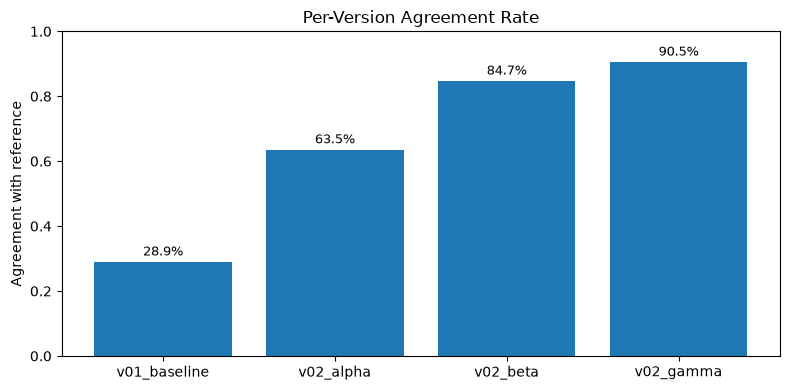

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(version_summary["version"], version_summary["agreement_rate"])
ax.set_ylabel("Agreement with reference")
ax.set_title("Per-Version Agreement Rate")
ax.set_ylim(0, 1)
for i, row in version_summary.iterrows():
    ax.text(i, row["agreement_rate"] + 0.02, f"{row['agreement_rate']:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Score by Question Type

In [ ]:
def _get_route(qid: str, vname: str) -> str:
    """Prefer trace route; fall back to parser/router prediction."""
    if vname in traces:
        tdf = traces[vname]
        match = tdf.loc[tdf["qid"] == qid, "route"]
        if not match.empty:
            return str(match.iloc[0])
    match = questions_df.loc[questions_df["qid"] == qid, "route_predicted"]
    if not match.empty:
        return str(match.iloc[0])
    return "unknown"

type_rows = []
for vname in version_order:
    sdf = submissions[vname]
    merged = ref_df.merge(sdf, on="qid", how="left", suffixes=("_ref", "_sub"))
    merged["agrees"] = merged["answer_ref"] == merged["answer_sub"]
    merged["route"] = merged["qid"].apply(lambda qid: _get_route(qid, vname))
    for route, grp in merged.groupby("route"):
        type_rows.append({
            "version": vname,
            "question_type": route,
            "n": len(grp),
            "agreement_rate": round(grp["agrees"].mean(), 4),
            "disagree_count": int((~grp["agrees"]).sum()),
        })

type_summary = pd.DataFrame(type_rows)
display(type_summary.pivot_table(index="question_type", columns="version",
                                  values="agreement_rate", aggfunc="first").round(4))
type_summary.to_csv(REPORTS_DIR / "question_type_summary.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'question_type_summary.csv'}")

version,v01_baseline,v02_alpha,v02_beta,v02_gamma
question_type,,,,
None,0.2894,NaN,NaN,NaN
knowledge,NaN,0.6783,0.7063,0.8182
reading,NaN,0.7600,0.8000,0.9500
safety,NaN,1.0000,1.0000,1.0000
stem,NaN,0.5417,0.9583,0.9398


Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/question_type_summary.csv


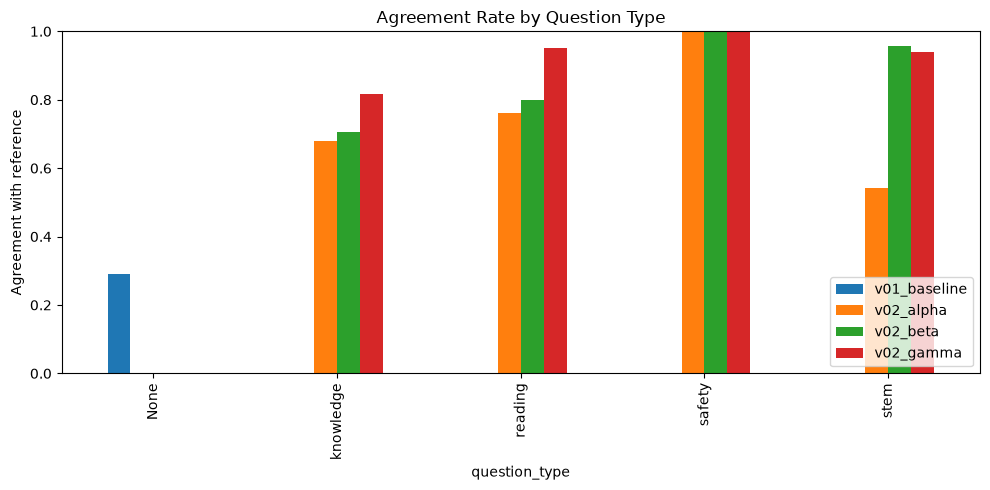

In [ ]:
pivot = type_summary.pivot_table(index="question_type", columns="version",
                                  values="agreement_rate", aggfunc="first")
pivot = pivot[version_order]  # consistent column order
pivot.plot.bar(figsize=(10, 5))
plt.ylabel("Agreement with reference")
plt.title("Agreement Rate by Question Type")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Delta Analyzer

In [ ]:
delta_rows = []
fixed_qids_all: dict[str, list[str]] = {}
broken_qids_all: dict[str, list[str]] = {}
unchanged_wrong_all: dict[str, list[str]] = {}

for i in range(len(version_order) - 1):
    v_prev, v_curr = version_order[i], version_order[i + 1]
    transition = f"{v_prev} -> {v_curr}"

    prev_df = submissions[v_prev].set_index("qid")["answer"]
    curr_df = submissions[v_curr].set_index("qid")["answer"]
    ref_s = ref_df.set_index("qid")["answer"]

    common = sorted(set(prev_df.index) & set(curr_df.index) & set(ref_s.index))

    unchanged_agrees = 0
    unchanged_disagrees = 0
    changed_toward = 0
    changed_away = 0
    changed_both_wrong = 0
    fixed, broken, uw = [], [], []

    for qid in common:
        p, c, r = prev_df[qid], curr_df[qid], ref_s[qid]
        if p == c:
            if c == r:
                unchanged_agrees += 1
            else:
                unchanged_disagrees += 1
                uw.append(qid)
        else:
            if c == r and p != r:
                changed_toward += 1
                fixed.append(qid)
            elif p == r and c != r:
                changed_away += 1
                broken.append(qid)
            else:
                changed_both_wrong += 1

    delta_rows.append({
        "transition": transition,
        "n": len(common),
        "unchanged_agrees": unchanged_agrees,
        "unchanged_disagrees": unchanged_disagrees,
        "changed_toward_ref": changed_toward,
        "changed_away_from_ref": changed_away,
        "changed_both_wrong": changed_both_wrong,
        "net_gain": changed_toward - changed_away,
    })
    fixed_qids_all[transition] = fixed
    broken_qids_all[transition] = broken
    unchanged_wrong_all[transition] = uw

delta_df = pd.DataFrame(delta_rows)
display(delta_df)
delta_df.to_csv(REPORTS_DIR / "version_deltas.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'version_deltas.csv'}")

,transition,n,unchanged_agrees,unchanged_disagrees,changed_toward_ref,changed_away_from_ref,changed_both_wrong,net_gain
0,v01_baseline -> v02_alpha,463,106,76,188,28,65,160
1,v02_alpha -> v02_beta,463,291,62,101,3,6,98
2,v02_beta -> v02_gamma,463,375,21,44,17,6,27


Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/version_deltas.csv


In [ ]:
for transition in delta_df["transition"]:
    print(f"\n=== {transition} ===")
    print(f"  Fixed ({len(fixed_qids_all[transition])}):  {fixed_qids_all[transition][:10]}{'...' if len(fixed_qids_all[transition]) > 10 else ''}")
    print(f"  Broken ({len(broken_qids_all[transition])}): {broken_qids_all[transition][:10]}{'...' if len(broken_qids_all[transition]) > 10 else ''}")
    print(f"  Unchanged-wrong ({len(unchanged_wrong_all[transition])}): {unchanged_wrong_all[transition][:10]}{'...' if len(unchanged_wrong_all[transition]) > 10 else ''}")


=== v01_baseline -> v02_alpha ===
  Fixed (188):  ['test_0003', 'test_0004', 'test_0006', 'test_0007', 'test_0013', 'test_0014', 'test_0015', 'test_0020', 'test_0023', 'test_0024']...
  Broken (28): ['test_0008', 'test_0043', 'test_0045', 'test_0049', 'test_0063', 'test_0065', 'test_0066', 'test_0071', 'test_0072', 'test_0081']...
  Unchanged-wrong (76): ['test_0005', 'test_0010', 'test_0011', 'test_0018', 'test_0019', 'test_0022', 'test_0025', 'test_0029', 'test_0030', 'test_0046']...

=== v02_alpha -> v02_beta ===
  Fixed (101):  ['test_0002', 'test_0005', 'test_0008', 'test_0009', 'test_0018', 'test_0021', 'test_0025', 'test_0029', 'test_0043', 'test_0051']...
  Broken (3): ['test_0254', 'test_0274', 'test_0452']
  Unchanged-wrong (62): ['test_0010', 'test_0011', 'test_0019', 'test_0022', 'test_0030', 'test_0045', 'test_0046', 'test_0049', 'test_0066', 'test_0074']...

=== v02_beta -> v02_gamma ===
  Fixed (44):  ['test_0010', 'test_0011', 'test_0019', 'test_0022', 'test_0045', 'te

## 5. Persistent Failure Set

In [ ]:
# Build wide answer matrix
answer_matrix = ref_df[["qid", "answer"]].copy().rename(columns={"answer": "ref_answer"})
for vname in version_order:
    sdf = submissions[vname][["qid", "answer"]].rename(columns={"answer": vname})
    answer_matrix = answer_matrix.merge(sdf, on="qid", how="left")

# Agreement flags
for vname in version_order:
    answer_matrix[f"{vname}_agrees"] = answer_matrix[vname] == answer_matrix["ref_answer"]

agree_cols = [f"{v}_agrees" for v in version_order]
answer_matrix["all_disagree"] = ~answer_matrix[agree_cols].any(axis=1)
answer_matrix["disagree_count"] = (~answer_matrix[agree_cols]).sum(axis=1)

persistent = answer_matrix[answer_matrix["all_disagree"]].copy()

# Attach question text, options, and predicted route
persistent = persistent.merge(
    questions_df[["qid", "question", "options", "route_predicted"]], on="qid", how="left"
)

display_cols = ["qid", "ref_answer"] + version_order + ["route_predicted", "question"]
print(f"Persistent failures (disagree across ALL versions): {len(persistent)}")
display(persistent[display_cols].head(20))

persistent[display_cols].to_csv(REPORTS_DIR / "persistent_failures.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'persistent_failures.csv'}")

Persistent failures (disagree across ALL versions): 21


,qid,ref_answer,v01_baseline,v02_alpha,v02_beta,v02_gamma,route_predicted,question
0,test_0030,B,A,A,A,A,knowledge,Người đầu tiên truyền thừa tại chùa An Phú là ai?
1,test_0058,B,A,A,C,C,stem,"Thời hạn giải quyết thủ tục cấp giấy phép xây dựng (cải tạo, nâng cấp đường ngang) của Bộ Xây dựng là bao nhiêu ngày..."
2,test_0070,B,A,A,C,C,stem,"Theo quy trình cấp Chứng nhận trường mầm non đạt kiểm định chất lượng giáo dục, thành phần hồ sơ bắt buộc gồm những ..."
3,test_0074,B,A,A,A,A,knowledge,Thế gian trụ trì Phật bảo là chỉ cho gì?
4,test_0109,C,A,A,A,B,knowledge,Việc tăng giá xăng ảnh hưởng đến cầu du lịch Highland thông qua cơ chế nào trước?
5,test_0119,A,D,B,B,B,reading,Đoạn thông tin:\nTitle: Cổ Thiên Lạc\nContent: Cổ Thiên Lạc (sinh ngày 21 tháng 10 năm 1970) là một diễn viên và ca ...
6,test_0168,D,A,C,C,C,knowledge,"Theo Chủ Tịch Hồ Chí Minh, học để làm gì?"
7,test_0178,A,D,B,B,B,knowledge,Tri giác phản ánh điều gì?
8,test_0229,D,A,C,C,C,knowledge,Chủ Tịch Hồ Chí Minh xác định yếu tố nào là gốc của người cách mạng?
9,test_0230,B,D,C,C,C,knowledge,"Học thuyết chính trị của Xê-nô-phôn, nhà chính trị học phương Tây cổ đại chủ yếu bàn đến vấn đề gì của chính trị?"


Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/persistent_failures.csv


## 6. Regression Set

In [ ]:
regression_rows = []
for _, row in answer_matrix.iterrows():
    first_agrees = None
    for vname in version_order:
        if row[f"{vname}_agrees"]:
            if first_agrees is None:
                first_agrees = vname
        else:
            if first_agrees is not None:
                regression_rows.append({
                    "qid": row["qid"],
                    "ref_answer": row["ref_answer"],
                    "first_agrees_version": first_agrees,
                    "first_disagrees_version": vname,
                    **{v: row[v] for v in version_order},
                })
                break

regressions_df = pd.DataFrame(regression_rows)
print(f"Regressions (agreed earlier, then disagreed): {len(regressions_df)}")
if not regressions_df.empty:
    display(regressions_df.head(20))
else:
    print("(no regressions found)")

regressions_df.to_csv(REPORTS_DIR / "regressions.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'regressions.csv'}")

Regressions (agreed earlier, then disagreed): 48


,qid,ref_answer,first_agrees_version,first_disagrees_version,v01_baseline,v02_alpha,v02_beta,v02_gamma
0,test_0008,B,v01_baseline,v02_alpha,B,A,B,B
1,test_0043,E,v01_baseline,v02_alpha,E,A,E,E
2,test_0045,B,v01_baseline,v02_alpha,B,A,A,B
3,test_0047,A,v01_baseline,v02_gamma,A,A,A,B
4,test_0048,A,v01_baseline,v02_gamma,A,A,A,B
5,test_0049,B,v01_baseline,v02_alpha,B,A,A,B
6,test_0063,B,v01_baseline,v02_alpha,B,A,B,B
7,test_0065,D,v01_baseline,v02_alpha,D,A,B,D
8,test_0066,B,v01_baseline,v02_alpha,B,D,D,D
9,test_0071,C,v01_baseline,v02_alpha,C,A,C,C


Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/regressions.csv


## 7. Confidence & Vote Analysis (trace-based)

In [ ]:
if not traces:
    print("No trace files loaded — skipping confidence/vote analysis.")
else:
    ref_s = ref_df.set_index("qid")["answer"]
    margin_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
    margin_labels = ["[0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0]"]

    for vname in version_order:
        if vname not in traces:
            continue
        tdf = traces[vname].copy()
        tdf["agrees"] = tdf.apply(lambda r: r["answer"] == ref_s.get(r["qid"], None), axis=1)

        # --- Margin buckets ---
        if "margin" in tdf.columns and tdf["margin"].notna().any():
            tdf["margin_bucket"] = pd.cut(tdf["margin"].astype(float), bins=margin_bins,
                                           labels=margin_labels, right=False)
            margin_tab = tdf.groupby("margin_bucket", observed=False).agg(
                n=("agrees", "count"),
                agreement_rate=("agrees", "mean"),
            ).round(4)
            print(f"\n=== {vname}: Margin bucket vs agreement ===")
            display(margin_tab)

        # --- Vote pattern ---
        if "votes" in tdf.columns:
            def _vote_pattern(votes):
                if not isinstance(votes, list) or len(votes) == 0:
                    return "no_sc"
                return "unanimous" if len(set(votes)) == 1 else "split"

            tdf["vote_pattern"] = tdf["votes"].apply(_vote_pattern)
            vote_tab = tdf.groupby("vote_pattern").agg(
                n=("agrees", "count"),
                agreement_rate=("agrees", "mean"),
            ).round(4)
            print(f"\n=== {vname}: Vote pattern vs agreement ===")
            display(vote_tab)

        # --- Direct vs SC paths ---
        if "path" in tdf.columns:
            tdf["used_sc"] = tdf["path"].str.contains("_sc", na=False)
            path_tab = tdf.groupby("used_sc").agg(
                n=("agrees", "count"),
                agreement_rate=("agrees", "mean"),
            ).round(4)
            path_tab.index = path_tab.index.map({True: "SC path", False: "Direct path"})
            print(f"\n=== {vname}: Direct vs SC path ===")
            display(path_tab)


=== v01_baseline: Vote pattern vs agreement ===


,n,agreement_rate
vote_pattern,,
no_sc,463,0.2894



=== v01_baseline: Direct vs SC path ===


,n,agreement_rate
used_sc,,
Direct path,463,0.2894



=== v02_alpha: Margin bucket vs agreement ===


...

,n,agreement_rate
margin_bucket,,
"[0, 0.2)",0,NaN
"[0.2, 0.4)",0,NaN
"[0.4, 0.6)",0,NaN
"[0.6, 0.8)",0,NaN
"[0.8, 1.0]",459,0.9041



=== v02_gamma: Vote pattern vs agreement ===


,n,agreement_rate
vote_pattern,,
no_sc,463,0.905



=== v02_gamma: Direct vs SC path ===


,n,agreement_rate
used_sc,,
Direct path,232,0.8664
SC path,231,0.9437


## 8. S5 & RAG Impact (trace-based)

In [ ]:
if not traces:
    print("No trace files loaded — skipping S5/RAG analysis.")
else:
    ref_s = ref_df.set_index("qid")["answer"]

    for vname in version_order:
        if vname not in traces:
            continue
        tdf = traces[vname].copy()
        tdf["agrees"] = tdf.apply(lambda r: r["answer"] == ref_s.get(r["qid"], None), axis=1)

        print(f"\n{'='*60}")
        print(f"=== {vname} ===")
        print(f"{'='*60}")

        # --- S5: Route override ---
        if "route_override" in tdf.columns:
            overrides = tdf[tdf["route_override"] == True]
            print(f"\nS5 route overrides: {len(overrides)} / {len(tdf)}")
            if not overrides.empty and "layer1_route" in tdf.columns:
                pairs = overrides.groupby(["layer1_route", "route"]).size().reset_index(name="count")
                print("  Route override pairs (layer1 -> final):")
                display(pairs)

                toward = overrides[overrides["agrees"]].shape[0]
                away = overrides[~overrides["agrees"]].shape[0]
                print(f"  Overrides toward reference: {toward}")
                print(f"  Overrides away from reference: {away}")
        else:
            print("  (no route_override field in trace)")

        # --- RAG ---
        if "rag_used" in tdf.columns:
            rag_count = (tdf["rag_used"] == True).sum()
            print(f"\nRAG used: {rag_count} / {len(tdf)}")
            if rag_count > 0 and "rag_top_score" in tdf.columns:
                rag_rows = tdf[tdf["rag_used"] == True]
                toward = rag_rows[rag_rows["agrees"]].shape[0]
                away = rag_rows[~rag_rows["agrees"]].shape[0]
                print(f"  RAG toward reference: {toward}")
                print(f"  RAG away from reference: {away}")
                scores = rag_rows["rag_top_score"].dropna()
                if not scores.empty:
                    print(f"  RAG top score: mean={scores.mean():.3f}, median={scores.median():.3f}")
            elif rag_count == 0:
                print("  (final-compliant runners have rag_used=false throughout)")
        else:
            print("  (no rag_used field in trace)")


=== v01_baseline ===

S5 route overrides: 0 / 463

RAG used: 0 / 463
  (final-compliant runners have rag_used=false throughout)

=== v02_alpha ===

S5 route overrides: 0 / 463

RAG used: 0 / 463
  (final-compliant runners have rag_used=false throughout)

=== v02_beta ===

S5 route overrides: 0 / 463

RAG used: 0 / 463
  (final-compliant runners have rag_used=false throughout)

=== v02_gamma ===

S5 route overrides: 0 / 463

RAG used: 0 / 463
  (final-compliant runners have rag_used=false throughout)


## 9. Question Browser

Edit `INSPECT_QID` and `INSPECT_VERSION` in the Parameters cell, then re-run this section.

In [ ]:
# --- Question details ---
q_match = questions_df[questions_df["qid"] == INSPECT_QID]
if q_match.empty:
    print(f"qid '{INSPECT_QID}' not found in questions.")
else:
    q_row = q_match.iloc[0]
    print(f"QID: {INSPECT_QID}")
    print(f"Question: {q_row['question']}")
    print(f"\nOptions:")
    for label, text in sorted(q_row["options"].items()):
        print(f"  {label}) {text}")
    print(f"\nPredicted route: {q_row['route_predicted']}")

    # Reference answer
    ref_match = ref_df[ref_df["qid"] == INSPECT_QID]
    ref_ans = ref_match.iloc[0]["answer"] if not ref_match.empty else "(not in reference)"
    print(f"Reference answer: {ref_ans}")

    # All versions
    print(f"\nVersion answers:")
    for vname in version_order:
        sdf = submissions[vname]
        s_match = sdf[sdf["qid"] == INSPECT_QID]
        if s_match.empty:
            print(f"  {vname}: (missing)")
        else:
            ans = s_match.iloc[0]["answer"]
            agrees = "agrees" if ans == ref_ans else "DISAGREES"
            print(f"  {vname}: {ans}  ({agrees})")

    # Trace for INSPECT_VERSION
    print(f"\n--- Trace detail: {INSPECT_VERSION} ---")
    if INSPECT_VERSION in traces:
        tdf = traces[INSPECT_VERSION]
        t_match = tdf[tdf["qid"] == INSPECT_QID]
        if t_match.empty:
            print(f"  (no trace for qid '{INSPECT_QID}' in {INSPECT_VERSION})")
        else:
            t_row = t_match.iloc[0]
            trace_fields = ["route", "path", "margin", "first_answer", "votes",
                            "layer1_route", "semantic_route", "route_override",
                            "rag_used", "rag_top_score", "error"]
            for field in trace_fields:
                if field in t_row.index:
                    print(f"  {field}: {t_row[field]}")
    else:
        print(f"  (no trace loaded for {INSPECT_VERSION})")

QID: test_0001
Question: Đoạn thông tin:
[1] Tiêu đề: Ném đá
Nội dung: Thạch hình là một phương pháp tử hình trong đó một nhóm người ném đá vào người cho đến khi đối tượng chết vì chấn thương cùn. Nó đã được chứng thực như một hình thức trừng phạt cho những hành vi sai trái nghiêm trọng từ thời cổ đại. Việc áp dụng nó trong một số hệ thống pháp lý đã gây ra tranh cãi trong những thập kỷ gần đây.
Torah và Talmud quy định ném đá là hình phạt cho một số hành vi phạm tội. Trong nhiều thế kỷ, Do Thái giáo Rabbinic đã phát triển một số hạn chế về thủ tục khiến cho các luật này thực tế không thể thực thi được. Mặc dù ném đá không được đề cập trong Kinh Qur'an, luật học Hồi giáo cổ điển (fiqh) đã áp đặt ném đá như một hình phạt hadd (mô tả trong sharia) đối với một số hình thức zina (giao hợp bất hợp pháp) trên cơ sở của hadith (những lời nói và hành động được gán cho nhà tiên tri Hồi giáo Muhammad). Nó cũng phát triển một số yêu cầu về thủ tục khiến zina hầu như không thể chứng minh trong thự

## Save Final Artifacts

In [ ]:
# --- per_question_matrix.csv ---
# One row per qid: ref answer, all version answers, agree flags, route, margin
matrix = answer_matrix.copy()
matrix = matrix.merge(questions_df[["qid", "route_predicted"]], on="qid", how="left")

# Attach margin from the latest version that has a trace
margin_source = version_order[-1] if version_order[-1] in traces else None
if margin_source and "margin" in traces[margin_source].columns:
    margin_df = traces[margin_source][["qid", "margin"]].copy()
    matrix = matrix.merge(margin_df, on="qid", how="left")

matrix.to_csv(REPORTS_DIR / "per_question_matrix.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'per_question_matrix.csv'} ({len(matrix)} rows)")

# --- audit_queue.csv ---
# Union of persistent failures + regressions, sorted by failure severity
audit_qids = set()
if not persistent.empty:
    audit_qids |= set(persistent["qid"])
if not regressions_df.empty:
    audit_qids |= set(regressions_df["qid"])

audit = answer_matrix[answer_matrix["qid"].isin(audit_qids)].copy()
audit = audit.merge(questions_df[["qid", "question", "route_predicted"]], on="qid", how="left")
audit = audit.sort_values("disagree_count", ascending=False)

audit_cols = ["qid", "disagree_count", "ref_answer"] + version_order + ["route_predicted", "question"]
audit_out = audit[[c for c in audit_cols if c in audit.columns]]
audit_out.to_csv(REPORTS_DIR / "audit_queue.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'audit_queue.csv'} ({len(audit_out)} rows)")

print(f"\nAll reports saved to: {REPORTS_DIR}/")
for f in sorted(REPORTS_DIR.glob("*.csv")):
    print(f"  {f.name}")

Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/per_question_matrix.csv (463 rows)
Saved: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/audit_queue.csv (69 rows)

All reports saved to: /Users/minhvietnguyen/Documents/hackaithon-innovator/reports/eval/
  audit_queue.csv
  per_question_matrix.csv
  persistent_failures.csv
  question_type_summary.csv
  regressions.csv
  version_deltas.csv
  version_summary.csv
